In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

df = pd.read_csv("loan_eligibility.csv")

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns


In [5]:
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

In [6]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [9]:

df = pd.get_dummies(df, drop_first=True)
if "Loan_Status" not in df.columns:
    raise ValueError("Target column 'Loan_Status' not found in dataset.")

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\nModel Accuracy: {accuracy:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Accuracy: 81.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.40      0.56        35
           1       0.80      0.99      0.88        85

    accuracy                           0.82       120
   macro avg       0.87      0.69      0.72       120
weighted avg       0.84      0.82      0.79       120


Confusion Matrix:
[[14 21]
 [ 1 84]]


In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

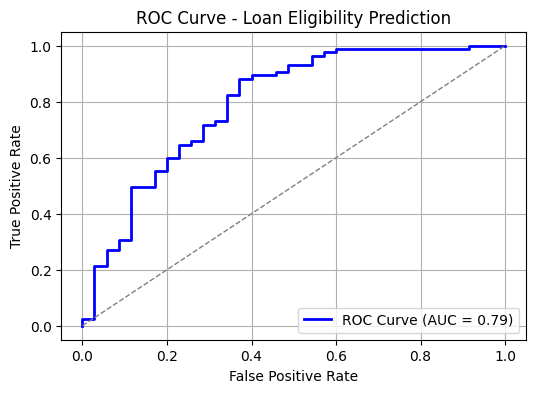

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Eligibility Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

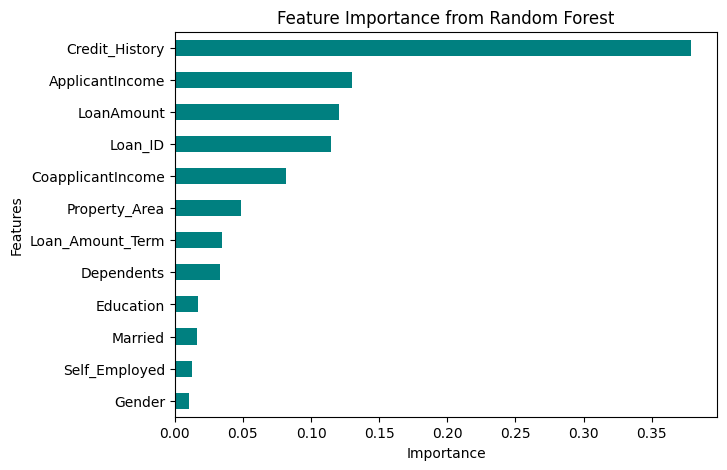

In [22]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values().plot(kind="barh", color="teal", figsize=(7, 5))
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()
